[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jiyunlee-research-lab/lecture-notebooks/blob/main/notebooks/lecture_8.ipynb)

# Lecture 8 Exercises

Learning objectives:
1. Learn about the expectation operator
2. Learn how to draw random samples from a CDF
3. Compare the sample mean value with the expected value (true mean)

Make sure to run all cells in order to avoid any issues. The cell below loads libraries and functions needed for this exercise (you don't have to worry about the details, you only need to run it).

In [ ]:
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import urllib.request
    Path("functions").mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/jiyunlee-research-lab/lecture-notebooks/main/notebooks/functions/l02.py",
        "functions/l02.py",
    )

sys.path.insert(0, str(Path.cwd() / "functions"))
from l02 import *
import numpy as np
import pandas as pd


## Example: Expected Damage States for a Building

Refer to Example 2 (lecture 8). Assuming that our building is subject to a VII magnitude earthquake and will experience a 0.02 interstory drift ratio, the damage state $\Theta$ is a discrete random variable that can take one of three values: $\theta_1$ (Slight Damage), $\theta_2$ (Moderate Damage), or $\theta_3$ (Severe Damage). Its probability mass function (PMF) is:

$$P(\Theta = \theta_1) = 0.1, \quad P(\Theta = \theta_2) = 0.6, \quad P(\Theta = \theta_3) = 0.3$$

Summing these up gives us the cumulative distribution function (CDF):

$$F_\Theta(\theta) = P(\Theta \le \theta) = \begin{cases} 0 & \theta < \theta_1 \\ 0.1 & \theta_1 \le \theta < \theta_2 \\ 0.7 & \theta_2 \le \theta < \theta_3 \\ 1.0 & \theta \ge \theta_3 \end{cases}$$

Run the cell below to define and visualize the CDF

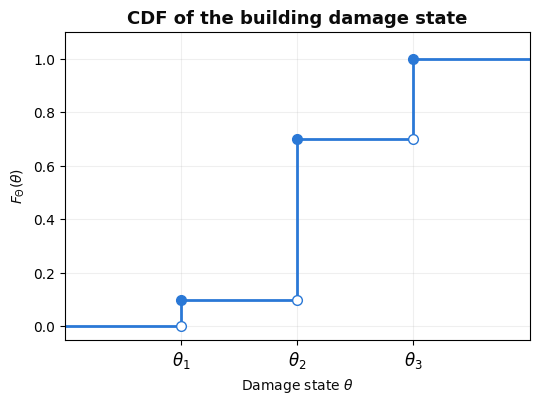

In [2]:
theta_1 = 0.1
theta_2 = 0.6
theta_3 = 0.3
plot_damage_cdf(theta_1, theta_2, theta_3)

We want to draw a large number of random samples from this CDF and find the expected damage state by calculating the sample mean.

To do that, let's first represent our damage states on a horizontal bar that goes from 0.0 to 1.0 (lower and upper limits of a CDF)


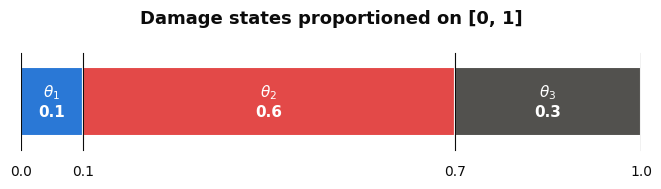

In [3]:
plot_damage_bar(theta_1, theta_2, theta_3)

We can visually draw a random sample from this CDF by generating a random number between 0.0 and 1.0 (uniformly distributed), then finding out where it lands on the horizontal bar. This is equivalent to finding the inverse CDF value of this random number.

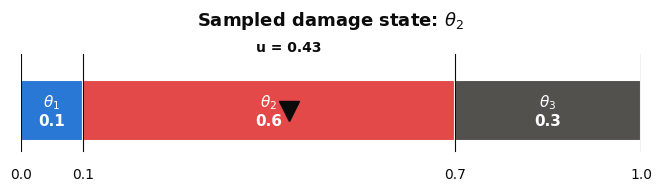

np.int64(2)

In [23]:
sample_damage_state(theta_1, theta_2, theta_3)

Lets now draw a larger number of samples and find their mean, which should represent the expected damage state.

In [13]:
n_points = 100
samples = sample_damage_states(n_points, theta_1, theta_2, theta_3)
pd.DataFrame({"sample": samples})

,sample
0,2
1,2
2,2
3,1
4,2
...,...
95,1
96,2
97,3
98,3


In [14]:
print(f"Sample mean (expected damage state): {samples.mean():.4f}")

Sample mean (expected damage state): 2.2300


Now if we define a cost for each damage state, we can calculate the expected loss for this building.

Define the probabilities of each damage state and cost based on our in-class example and see if you get the same answer.

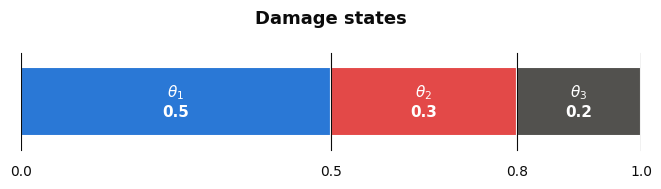

Theoretical expected cost: $10,900,000.00
Sample mean cost:          $10,840,000.00


(10900000.0, np.float64(10840000.0))

In [24]:
# Alternative 1
theta_1 = 0.5
theta_2 = 0.3
theta_3 = 0.2
cost_1 = 10000000
cost_2 = 11000000
cost_3 = 13000000
n_points = 100

plot_damage_bar(theta_1, theta_2, theta_3)
expected_cost(n_points, theta_1, theta_2, theta_3, cost_1, cost_2, cost_3)

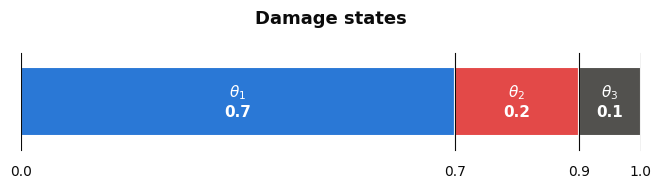

Theoretical expected cost: $12,600,000.00
Sample mean cost:          $12,624,000.00


(12600000.0, np.float64(12624000.0))

In [25]:
# Alternative 2
theta_1 = 0.7
theta_2 = 0.2
theta_3 = 0.1
cost_1 = 12000000
cost_2 = 13200000
cost_3 = 15600000
n_points = 100

plot_damage_bar(theta_1, theta_2, theta_3)
expected_cost(n_points, theta_1, theta_2, theta_3, cost_1, cost_2, cost_3)